# AUTOENCODER (MNIST)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (60000, 784)
Test shape: (10000, 784)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.2458 - val_loss: 0.1665
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1516 - val_loss: 0.1366
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1293 - val_loss: 0.1215
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1187 - val_loss: 0.1141
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1133 - val_loss: 0.1096
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1091 - val_loss: 0.1064
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1057 - val_loss: 0.1028
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1027 - val_loss: 0.1006
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1008 - val_loss: 0.0992
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0993 - val_loss: 0.0979


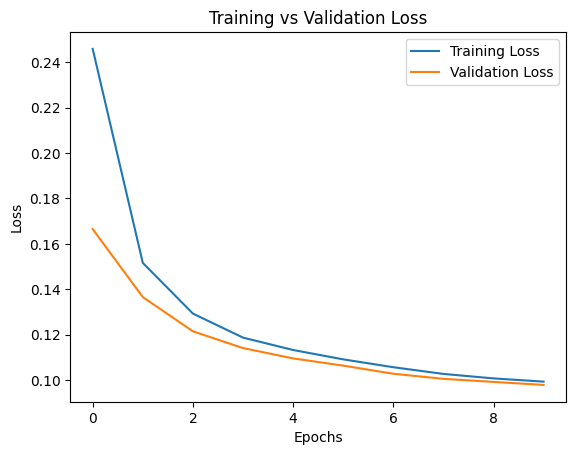

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


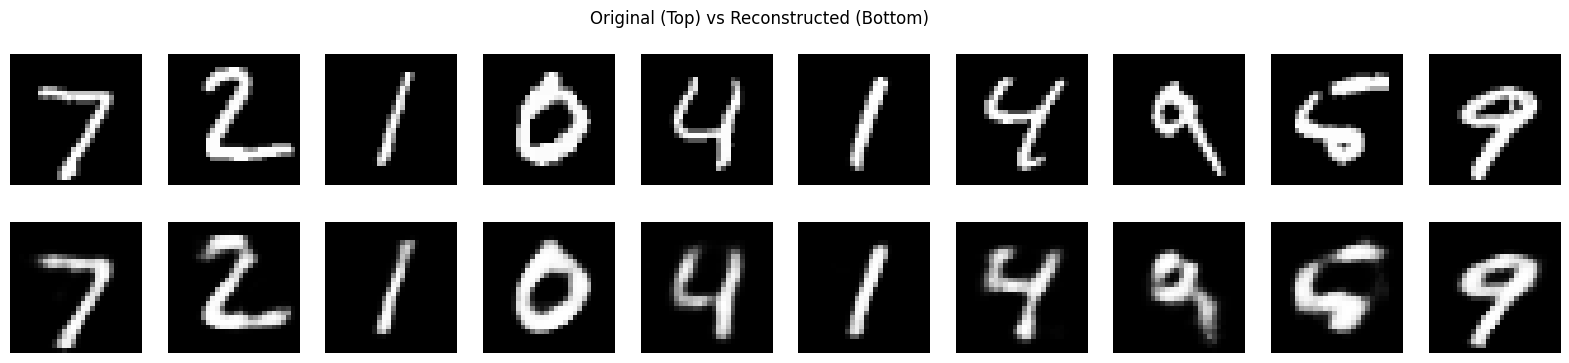

In [ ]:
# =========================
# AUTOENCODER - MNIST
# =========================

# Install TensorFlow
!pip install tensorflow

# Imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import backend as K

# =========================
# LOAD DATA
# =========================

(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# =========================
# MODEL DESIGN
# =========================

input_dim = 784
encoding_dim = 32  # latent space

# Encoder
input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder Model
autoencoder = Model(inputs=input_img, outputs=output)

# =========================
# COMPILE MODEL
# =========================

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# MODEL SUMMARY
# =========================

autoencoder.summary()

# =========================
# TRAIN MODEL
# =========================

history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# =========================
# LOSS CURVE
# =========================

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# =========================
# RECONSTRUCTION
# =========================

decoded_imgs = autoencoder.predict(x_test)

# Display original vs reconstructed
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.axis('off')

plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
plt.show()

## Model Design
The autoencoder consists of two main parts: an encoder and a decoder. The encoder compresses the 28×28 input image into a lower-dimensional latent representation. The decoder reconstructs the original image from this compressed form.

## Training & Performance
The model was trained on the MNIST dataset using binary cross-entropy loss and the Adam optimizer. The training and validation loss decreased steadily, indicating effective learning.

## Reconstruction Results
The reconstructed images are very similar to the original images, with slight blurring due to compression. This shows that the model successfully learned important features.